# GRU (Gated Recurrent Unit) — Time-Series Prediction on Airline Passengers

This notebook demonstrates how to build a **GRU** for **time-series forecasting** using **PyTorch**.

**What you will learn:**
- How GRUs work and how they differ from LSTMs
- How to prepare time-series data with sliding windows
- How to normalize and denormalize data for prediction
- How to train a sequence-to-one regression model
- How to visualize predictions vs actual values

**Dataset:** International Airline Passengers — Classic time-series dataset with 144 monthly data points (Jan 1949 – Dec 1960) showing the number of airline passengers (in thousands).

The data is embedded directly in this notebook (no download needed).

## Step 1 — Install Required Packages

In [1]:
!pip install torch matplotlib numpy --quiet

## Step 2 — Imports & Device Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Step 3 — Load & Visualize the Data

The Airline Passengers dataset shows a clear **upward trend** and **seasonal pattern** (more passengers in summer). This makes it a good test for time-series models.

Data points: 144
Range: 104 to 622 (thousands of passengers)


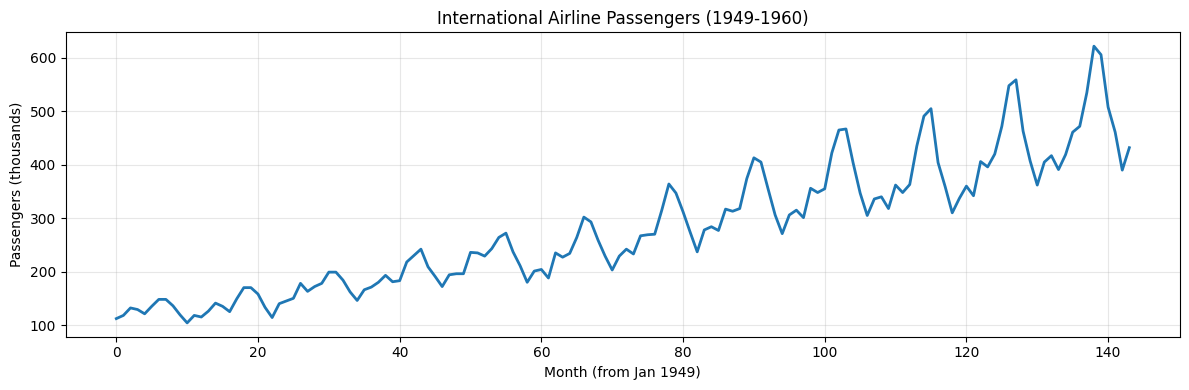

In [3]:
# International Airline Passengers: monthly totals (in thousands), Jan 1949 – Dec 1960
data = np.array([
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432
], dtype=np.float32)

print(f"Data points: {len(data)}")
print(f"Range: {data.min():.0f} to {data.max():.0f} (thousands of passengers)")

# Plot the full series
plt.figure(figsize=(12, 4))
plt.plot(data, linewidth=2)
plt.xlabel('Month (from Jan 1949)')
plt.ylabel('Passengers (thousands)')
plt.title('International Airline Passengers (1949-1960)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Normalize the Data

Neural networks work best with inputs in a small range. We use **Min-Max normalization** to scale all values to [0, 1].

$$x_{normalized} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

We'll save the min and max to **inverse-transform** predictions back to the original scale later.

In [4]:
# Min-Max normalization
data_min = data.min()
data_max = data.max()
data_normalized = (data - data_min) / (data_max - data_min)

print(f"Original range: [{data_min}, {data_max}]")
print(f"Normalized range: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]")

def inverse_normalize(x):
    """Convert normalized values back to original scale."""
    return x * (data_max - data_min) + data_min

Original range: [104.0, 622.0]
Normalized range: [0.0000, 1.0000]


## Step 5 — Create Sliding Window Sequences

For time-series prediction, we use a **sliding window** approach:
- Given a window of `seq_len` consecutive data points, predict the **next** value
- Example with `seq_len=3`: `[112, 118, 132]` → predict `129`

```
Window 1: [x₁, x₂, x₃]      → y₁ = x₄
Window 2: [x₂, x₃, x₄]      → y₂ = x₅
Window 3: [x₃, x₄, x₅]      → y₃ = x₆
...and so on
```

We use `seq_len=12` (12 months = 1 year) which captures the seasonal pattern.

In [5]:
SEQ_LEN = 12  # Use 12 months to predict the next month

def create_sequences(data, seq_len):
    """
    Create input-output pairs with sliding windows.
    
    Args:
        data: 1D array of normalized values
        seq_len: Number of timesteps to use as input
    
    Returns:
        X: Array of shape (num_samples, seq_len)
        y: Array of shape (num_samples,)
    """
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])        # Input: seq_len consecutive values
        y.append(data[i + seq_len])             # Target: the next value
    return np.array(X), np.array(y)

X, y = create_sequences(data_normalized, SEQ_LEN)

print(f"Total sequences: {len(X)}")
print(f"Input shape: {X.shape}  (num_samples, seq_len)")
print(f"Target shape: {y.shape}  (num_samples,)")
print(f"\nExample:")
print(f"  Input (12 months):  {X[0].round(3)}")
print(f"  Target (next month): {y[0]:.3f}")

Total sequences: 132
Input shape: (132, 12)  (num_samples, seq_len)
Target shape: (132,)  (num_samples,)

Example:
  Input (12 months):  [0.015 0.027 0.054 0.048 0.033 0.06  0.085 0.085 0.062 0.029 0.    0.027]
  Target (next month): 0.021


## Step 6 — Train/Test Split

For time-series, we split **chronologically** (not randomly!) — we train on earlier data and test on later data. This simulates real-world forecasting where you can't use future data.

We use the first **80%** for training and the last **20%** for testing.

In [6]:
# Chronological split
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Split at index: {split_idx} (month {split_idx + SEQ_LEN})")

Training samples: 105
Test samples: 27
Split at index: 105 (month 117)


## Step 7 — Dataset & DataLoader

We wrap our numpy arrays in a PyTorch Dataset. The GRU expects 3D input: `(batch_size, seq_len, num_features)`. Since we have a single feature (passenger count), `num_features=1`.

In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # Add feature dimension: (num_samples, seq_len) → (num_samples, seq_len, 1)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 16

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify shapes
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}  (batch, seq_len, features)")
print(f"Batch y shape: {sample_y.shape}  (batch,)")

Batch X shape: torch.Size([16, 12, 1])  (batch, seq_len, features)
Batch y shape: torch.Size([16])  (batch,)


## Step 8 — Define the GRU Model

Architecture:
```
Input (batch, seq_len, 1)
  → GRU(input_size=1, hidden_size=64, num_layers=2)
  → Take last hidden state → (batch, 64)
  → Linear(64, 1) → (batch, 1) — predicted next value
```

**How GRU differs from LSTM:**

| | LSTM | GRU |
|---|---|---|
| **States** | 2: hidden ($h$) + cell ($c$) | 1: hidden ($h$) only |
| **Gates** | 3: forget, input, output | 2: reset ($r$), update ($z$) |
| **Parameters** | More | ~25% fewer |
| **Speed** | Slower | Faster |

**GRU equations at each timestep:**

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$  (update gate — how much to keep from old state)

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$  (reset gate — how much of old state to use for new candidate)

$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$  (candidate new state)

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$  (final state — blend old and new)

The **update gate** $z_t$ controls how much of the old hidden state to preserve. When $z_t \approx 0$, the GRU keeps the old state (long-term memory). When $z_t \approx 1$, it adopts the new candidate state.

In [8]:
class GRUPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(GRUPredictor, self).__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,     # 1 feature (passenger count)
            hidden_size=hidden_size,   # Size of the hidden state
            num_layers=num_layers,     # Stacked GRU layers
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, 1)  # Output: single predicted value
    
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (batch, seq_len, input_size)
        Returns:
            Prediction of shape (batch,)
        """
        # GRU output: (batch, seq_len, hidden_size), h_n: (num_layers, batch, hidden_size)
        gru_out, h_n = self.gru(x)
        
        # Use last hidden state from the top layer
        last_hidden = h_n[-1]  # (batch, hidden_size)
        
        # Predict next value
        output = self.fc(last_hidden)  # (batch, 1)
        return output.squeeze(1)       # (batch,)

# Hyperparameters
INPUT_SIZE = 1    # Single feature (passenger count)
HIDDEN_SIZE = 64
NUM_LAYERS = 2

model = GRUPredictor(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GRUPredictor(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 37,889


## Step 9 — Loss Function & Optimizer

- **MSELoss** (Mean Squared Error): Standard loss for regression tasks. Penalizes large errors more.
- **Adam optimizer**: With a learning rate of 0.001.

In [9]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss: MSELoss (Mean Squared Error)")
print("Optimizer: Adam (lr=0.001)")

Loss: MSELoss (Mean Squared Error)
Optimizer: Adam (lr=0.001)


## Step 10 — Training Loop

Since this is a small dataset (only 132 sequences), we train for **100 epochs** to let the model converge. We track both training and test loss to monitor for overfitting.

In [10]:
num_epochs = 100
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Evaluation ---
    model.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            epoch_test_loss += loss.item()
    
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] — "
              f"Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}")

print("\nTraining complete!")

Epoch [ 10/100] — Train Loss: 0.008852, Test Loss: 0.025073
Epoch [ 20/100] — Train Loss: 0.006538, Test Loss: 0.022659
Epoch [ 30/100] — Train Loss: 0.006244, Test Loss: 0.020215
Epoch [ 40/100] — Train Loss: 0.006019, Test Loss: 0.017044
Epoch [ 50/100] — Train Loss: 0.004815, Test Loss: 0.013744
Epoch [ 60/100] — Train Loss: 0.003827, Test Loss: 0.009571
Epoch [ 70/100] — Train Loss: 0.003090, Test Loss: 0.006176
Epoch [ 80/100] — Train Loss: 0.002211, Test Loss: 0.008473
Epoch [ 90/100] — Train Loss: 0.002034, Test Loss: 0.007622
Epoch [100/100] — Train Loss: 0.002246, Test Loss: 0.009517

Training complete!


## Step 11 — Plot Training & Test Loss

If training loss decreases but test loss increases, the model is **overfitting**. Ideally both should decrease together.

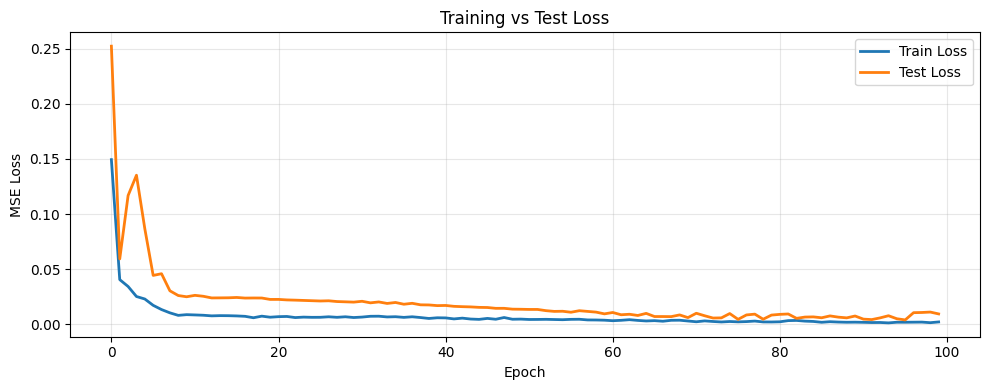

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12 — Generate Predictions & Visualize

We predict on **all** data (train + test) and plot the results. The vertical dashed line shows the train/test split point.

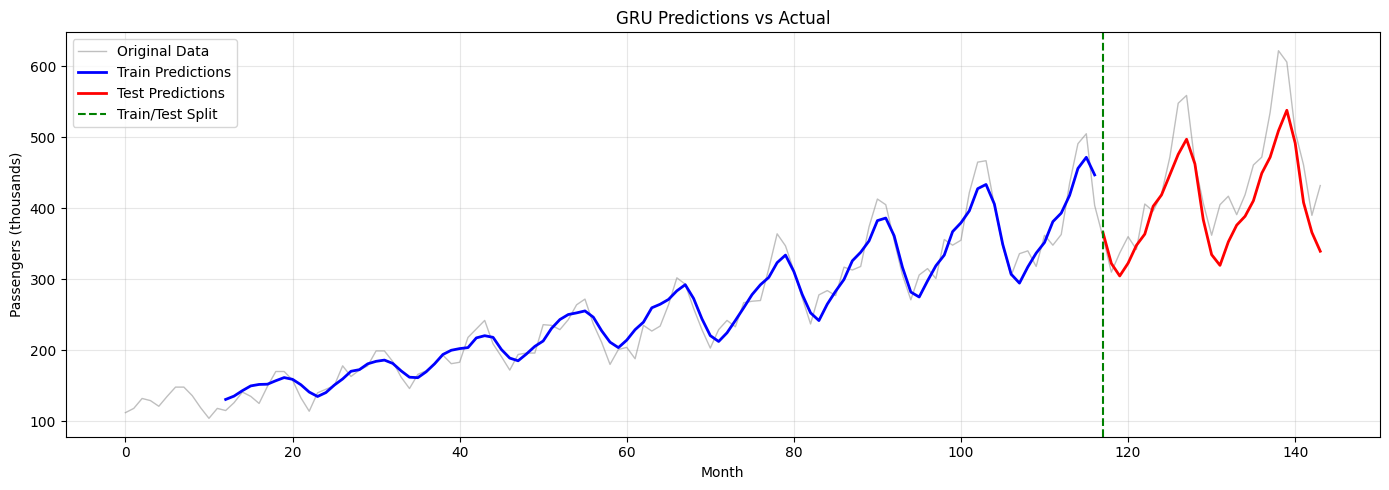

In [12]:
# Predict on ALL sequences
model.eval()
all_X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1).to(device)

with torch.no_grad():
    all_predictions = model(all_X).cpu().numpy()

# Inverse-normalize back to original scale
actual_values = inverse_normalize(y)
predicted_values = inverse_normalize(all_predictions)

# Time indices (shifted by SEQ_LEN since first prediction is at index SEQ_LEN)
time_indices = np.arange(SEQ_LEN, SEQ_LEN + len(y))

# Plot
plt.figure(figsize=(14, 5))
plt.plot(np.arange(len(data)), data, label='Original Data', color='gray', alpha=0.5, linewidth=1)
plt.plot(time_indices[:split_idx], predicted_values[:split_idx],
         label='Train Predictions', color='blue', linewidth=2)
plt.plot(time_indices[split_idx:], predicted_values[split_idx:],
         label='Test Predictions', color='red', linewidth=2)

# Mark train/test split
plt.axvline(x=split_idx + SEQ_LEN, color='green', linestyle='--', label='Train/Test Split', linewidth=1.5)

plt.xlabel('Month')
plt.ylabel('Passengers (thousands)')
plt.title('GRU Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 13 — Compute RMSE

**RMSE (Root Mean Squared Error)** is a common metric for regression:

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$$

It's in the same units as the data (thousands of passengers), making it interpretable.

In [13]:
# RMSE on train set
train_rmse = np.sqrt(np.mean((predicted_values[:split_idx] - actual_values[:split_idx]) ** 2))

# RMSE on test set
test_rmse = np.sqrt(np.mean((predicted_values[split_idx:] - actual_values[split_idx:]) ** 2))

print(f"Train RMSE: {train_rmse:.2f} (thousands of passengers)")
print(f"Test RMSE:  {test_rmse:.2f} (thousands of passengers)")

# For context: mean of test actual values
test_mean = actual_values[split_idx:].mean()
print(f"\nMean test value: {test_mean:.2f}")
print(f"Test RMSE as % of mean: {100 * test_rmse / test_mean:.1f}%")

Train RMSE: 18.76 (thousands of passengers)
Test RMSE:  48.90 (thousands of passengers)

Mean test value: 439.26
Test RMSE as % of mean: 11.1%


## Step 14 — Detailed Test Set Comparison

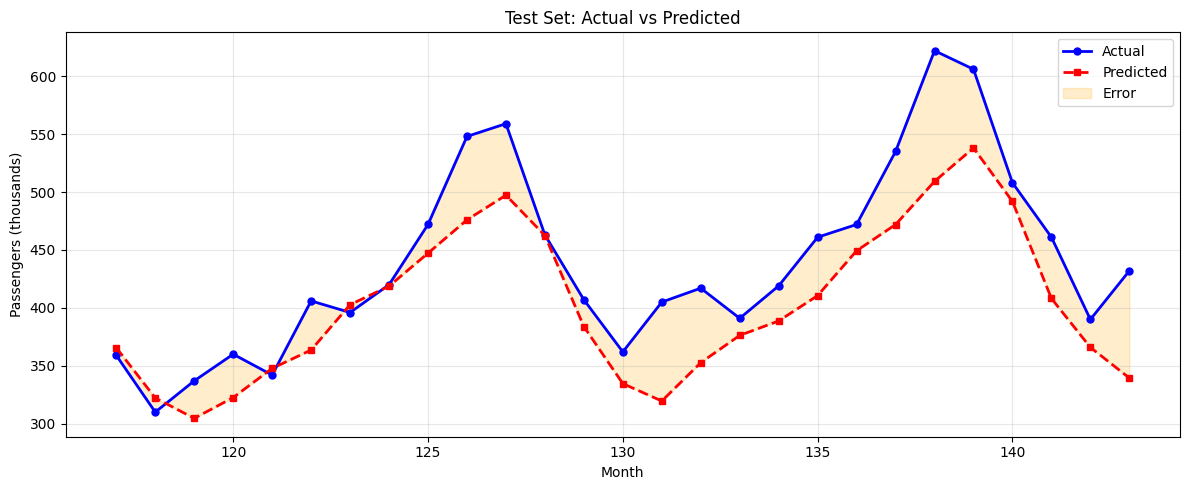

In [14]:
# Zoom into test set predictions
test_actual = actual_values[split_idx:]
test_pred = predicted_values[split_idx:]
test_time = time_indices[split_idx:]

plt.figure(figsize=(12, 5))
plt.plot(test_time, test_actual, 'o-', label='Actual', color='blue', linewidth=2, markersize=5)
plt.plot(test_time, test_pred, 's--', label='Predicted', color='red', linewidth=2, markersize=5)

# Fill the error area
plt.fill_between(test_time, test_actual, test_pred, alpha=0.2, color='orange', label='Error')

plt.xlabel('Month')
plt.ylabel('Passengers (thousands)')
plt.title('Test Set: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:
1. **Loaded** the Airline Passengers time-series dataset (144 monthly data points)
2. **Normalized** the data to [0, 1] using Min-Max scaling
3. **Created sliding windows** (12 months → predict next month)
4. **Split** chronologically into train (80%) and test (20%)
5. **Built** a GRU model with 2 layers and 64 hidden units
6. **Trained** for 100 epochs with MSELoss
7. **Visualized** predictions vs actual values and computed RMSE

**Key takeaways:**
- GRUs are efficient alternatives to LSTMs — fewer parameters, similar performance
- The **update gate** controls long-term vs short-term memory blending
- **Sliding window** is the standard approach for feeding time-series to RNNs/GRUs/LSTMs
- Chronological splits are essential for time-series (never shuffle!)
- Normalization is critical — the model works with small numbers much better

**Improvements to try:**
- Use a **bidirectional** GRU
- Add more **features** (e.g., month of year as a cyclical encoding)
- Try **multi-step prediction** (predict the next 6 months at once)
- Use a **learning rate scheduler** (`ReduceLROnPlateau`)